In [1]:
from MCMC_Algorithms.MCMC import *
from MCMC_Algorithms.Kernels import *

system path ['C:\\Users\\cwh38\\OneDrive - University Of Cambridge\\Documents\\cambridge-git\\ABC_SMC_RL', 'C:\\Users\\cwh38\\AppData\\Local\\miniconda3\\python39.zip', 'C:\\Users\\cwh38\\AppData\\Local\\miniconda3\\DLLs', 'C:\\Users\\cwh38\\AppData\\Local\\miniconda3\\lib', 'C:\\Users\\cwh38\\AppData\\Local\\miniconda3', '', 'C:\\Users\\cwh38\\AppData\\Local\\miniconda3\\lib\\site-packages', 'C:\\Users\\cwh38\\AppData\\Local\\miniconda3\\lib\\site-packages\\win32', 'C:\\Users\\cwh38\\AppData\\Local\\miniconda3\\lib\\site-packages\\win32\\lib', 'C:\\Users\\cwh38\\AppData\\Local\\miniconda3\\lib\\site-packages\\Pythonwin', '/scratch/Rabbit/work/ABC_SMC_RL/', '/Users/guojiaqi/work/ABC_SMC_RL/']


# 1

In [56]:
import torch

class Modeltest():
    def __init__(self, eps, sigma, z=0.5, r=-0.5):
        self.z = torch.tensor(z)
        self.eps = eps
        self.sigma = sigma
        self.r = torch.tensor(r)

    def logtarget_density(self, parameter, **kwargs):#para_extra_info):
        x = parameter[0]
        y = parameter[1]
        
        lp = torch.distributions.Normal(loc=torch.zeros(len(parameter)), scale=sigma).log_prob(parameter).sum()
        llh = torch.distributions.Normal(loc=x-torch.max(self.z, y), scale=eps).log_prob(self.r).sum()
        return lp+llh, None


    def logtarget_auto_gradient(self, parameter, llh_info_dict=dict()):
        parameter = parameter.clone()
        parameter.requires_grad = True
        logtarget_density, llh_info_dict = self.logtarget_density(parameter=parameter, llh_info_dict=llh_info_dict)
        logtarget_density.backward()
        gradient = parameter.grad.clone()
        parameter.grad.zero_()
        parameter.requires_grad = False
        logtarget_density = logtarget_density.detach()
        return logtarget_density, gradient, llh_info_dict
    
    def logtarget_auto_hessian(self, parameter):
        def fn(parameter):
            logtarget_density, _ = self.logtarget_density(parameter=parameter, llh_info_dict=dict())
            return logtarget_density
        return torch.autograd.functional.hessian(fn, parameter)

      def fn(parameter):
        current_logtarget_density, _ = Model.logtarget_density(parameter=parameter, llh_info_dict=dict())
        return current_logtarget_density
    torch.autograd.functional.hessian(fn, posterior_samples[mode_idx].reshape(-1)) - 1e-6 * torch.eye(len(posterior_samples[0].reshape(-1)))
    -torch.linalg.inv(hessian)
    
stepsize = 0.0019
num_samples = 50000

sigma=2
eps=0.001
model = Modeltest(eps=eps, sigma=sigma)
initial_params= torch.tensor([0.,0.]) 

hessian_params = initial_params
precondition_matrix = -torch.autograd.functional.hessian(model.logtarget_density, hessian_params) - 1e-6 * torch.eye(len(hessian_params))


#from MCMC import RandomWalk, MALA, MCMC, HMC, mMALA, mHMC
# #kerneltest = RandomWalk(model=Modeltest(), stepsize=stepsize)
# #kerneltest = RandomWalk(model=Modeltest(), stepsize=stepsize, covariance_matrix = torch.tensor([[.1]]))
# #kerneltest = MALA(model=Modeltest(), stepsize=stepsize, precondition_matrix = torch.tensor([[.1]]))
# kerneltest = MALA(model=Modeltest(), stepsize=stepsize, precondition_matrix = torch.tensor([[.1]]))
# #kerneltest = HMC(model=Modeltest(), stepsize=stepsize, num_steps=20)
# #kerneltest = HMC(model=Modeltest(), stepsize=stepsize, num_steps=20, precondition_matrix = torch.tensor([[0.1]]))
# #kerneltest = mMALA(model=Modeltest(), stepsize=stepsize)
# #kerneltest = mHMC(model=Modeltest(), stepsize=stepsize, num_steps=20)
kerneltest = HMC(model=model, stepsize=stepsize, num_steps=20, use_autograd=True, mass=1, precondition_matrix=None, traj_len=None)


mcmctest = MCMC(num_samples=num_samples, kernel=kerneltest, initial_params=initial_params, warmup_steps=0)
samplestest = mcmctest.run(idx=None).numpy()

# mcmctest = MCMC(num_samples=num_samples, kernel=kerneltest, initial_params=initial_params)
# samplestest = mcmctest.run()



HMC stepsize 0.0019


  0%|          | 0/50000 [00:00<?, ?it/s]

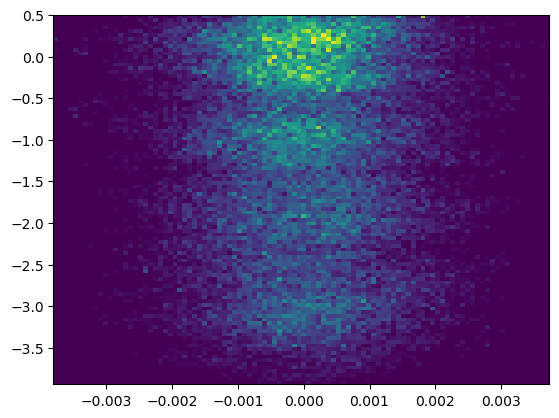

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
grid = np.linspace(-5,10,1000)
plt.hist2d(samplestest[:,0], samplestest[:,1], bins=100, density=True);
#plt.plot(grid, stats.laplace.pdf(grid, loc=2, scale=1));

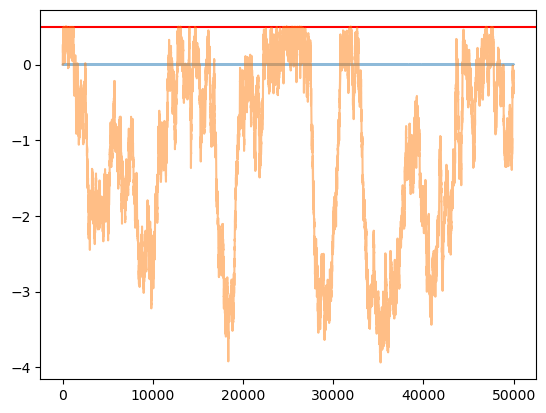

In [58]:
plt.figure()
plt.axhline(0.5, color="red")
plt.plot(samplestest[:,0], alpha=0.5)
plt.plot(samplestest[:,1], alpha=0.5)

# 2

In [78]:
precondition_matrix

tensor([[1000000.1250, -999999.8750],
        [-999999.8750, 1000000.1250]])

In [76]:
stepsize = 0.0000005
num_samples = 10000

sigma=2
eps=0.001
model = Modeltest(eps=eps, sigma=sigma)
initial_params= torch.tensor([1.,1.5]) 

hessian_params = initial_params
fn = lambda para: model.logtarget_density(para)[0]
precondition_matrix = -torch.autograd.functional.hessian(fn, hessian_params) - 1e-6 * torch.eye(len(hessian_params))

kerneltest = HMC(model=model, stepsize=stepsize, num_steps=20, use_autograd=True, mass=1, precondition_matrix=precondition_matrix, traj_len=None)


mcmctest = MCMC(num_samples=num_samples, kernel=kerneltest, initial_params=initial_params, warmup_steps=0)
samplestest = mcmctest.run(idx=None).numpy()


HMC stepsize 5e-07


  0%|          | 0/10000 [00:00<?, ?it/s]

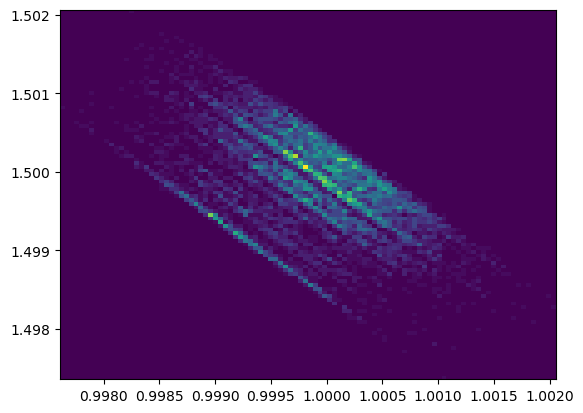

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
grid = np.linspace(-5,10,1000)
plt.hist2d(samplestest[:,0], samplestest[:,1], bins=100, density=True);
#plt.plot(grid, stats.laplace.pdf(grid, loc=2, scale=1));

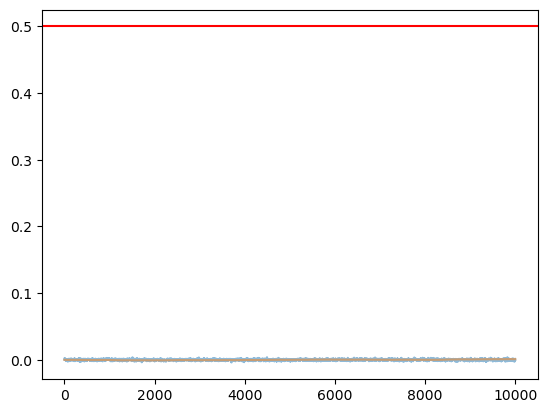

In [73]:
plt.figure()
plt.axhline(0.5, color="red")
plt.plot(samplestest[:,0], alpha=0.5)
plt.plot(samplestest[:,1], alpha=0.5)

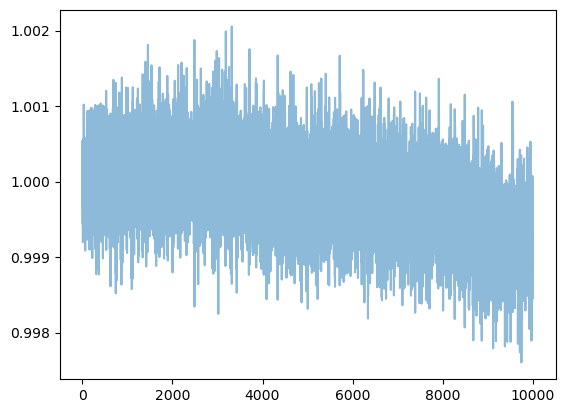

In [81]:
plt.figure()
plt.plot(samplestest[:,0], alpha=0.5)